In [3]:
# 肺癌患者生存分析：Kaplan-Meier 模型应用
# 运行前置：需安装依赖库 `pip install pandas numpy matplotlib lifelines`

%pip install lifelines

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4138 sha256=59be576d86670e979a2c3d4ddf4cf60292ad08b1b32e7267a73dbbabdf9142c1
  Stored in directory: c:\users\21626\appdata\local\pip\cache\wheels\25\cc\e0\ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma

   -------- ------------------------------- 1/5 [autograd]
   ---------------- ----------------------- 2/5 [autograd-gamma]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   -------------------------------- ------- 4/5 [lifelines]
   -------------------------------- ------- 4/5 [lifelines]
   ---------------------------------------- 5/5 [lifelines]

Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [2]:
###########################################################################
# 模块1：环境准备与数据探索（目的：导入工具库，了解数据集基本结构和特征）
###########################################################################
"""
模块1核心功能：
1. 导入生存分析所需的核心库
2. 读取肺癌生存数据集，进行初步探索（结构、字段、数据分布）
"""

# 导入数据处理库：pandas用于数据读取/处理，numpy用于数值计算
import pandas as pd
import numpy as np

# 导入可视化库：matplotlib用于绘制各类分析图表
import matplotlib.pyplot as plt

# 导入Kaplan-Meier生存估计模型（无参数生存分析核心模型）
from lifelines import KaplanMeierFitter

# 读取肺癌生存数据集（lung.csv为lifelines内置经典数据集，包含随访时间、生存状态等信息）
data = pd.read_csv("F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验十二/lung.csv")

# 查看数据集前5行，快速了解数据结构和字段内容
data.head()  # 解析：关键字段预览——time(随访天数)、status(生存状态)、sex(性别)等

# 打印数据集所有列名，明确可用字段
print("数据集列名：", data.columns)  # 解析：后续核心使用time(持续时间)和status(生存状态)字段

数据集列名： Index(['Unnamed: 0', 'inst', 'time', 'status', 'age', 'sex', 'ph.ecog',
       'ph.karno', 'pat.karno', 'meal.cal', 'wt.loss'],
      dtype='object')


In [6]:
# 设置中文字体，解决中文显示缺失问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于正常显示中文标签（黑体）
plt.rcParams['axes.unicode_minus'] = False  # 用于正常显示负号

In [3]:
# 查看数据集详细信息（数据类型、缺失值、样本量）
data.info()  # 解析：排查缺失值和数据类型是否合理，为后续预处理铺垫

# 查看数据集描述性统计（均值、中位数、四分位数等）
data.describe()  # 解析：把握数值型字段的分布特征，如随访时间的整体范围

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  228 non-null    int64  
 1   inst        227 non-null    float64
 2   time        228 non-null    int64  
 3   status      228 non-null    int64  
 4   age         228 non-null    int64  
 5   sex         228 non-null    int64  
 6   ph.ecog     227 non-null    float64
 7   ph.karno    227 non-null    float64
 8   pat.karno   225 non-null    float64
 9   meal.cal    181 non-null    float64
 10  wt.loss     214 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 19.7 KB


,Unnamed: 0,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
count,228.00000,227.000000,228.000000,228.000000,228.000000,228.000000,227.000000,227.000000,225.000000,181.000000,214.000000
mean,114.50000,11.088106,305.232456,1.723684,62.447368,1.394737,0.951542,81.938326,79.955556,928.779006,9.831776
std,65.96211,8.303491,210.645543,0.448159,9.073457,0.489870,0.717872,12.327955,14.623177,402.174707,13.139902
min,1.00000,1.000000,5.000000,1.000000,39.000000,1.000000,0.000000,50.000000,30.000000,96.000000,-24.000000
25%,57.75000,3.000000,166.750000,1.000000,56.000000,1.000000,0.000000,75.000000,70.000000,635.000000,0.000000
50%,114.50000,11.000000,255.500000,2.000000,63.000000,1.000000,1.000000,80.000000,80.000000,975.000000,7.000000
75%,171.25000,16.000000,396.500000,2.000000,69.000000,2.000000,1.000000,90.000000,90.000000,1150.000000,15.750000
max,228.00000,33.000000,1022.000000,2.000000,82.000000,2.000000,3.000000,100.000000,100.000000,2600.000000,68.000000


患者性别分布直方图：


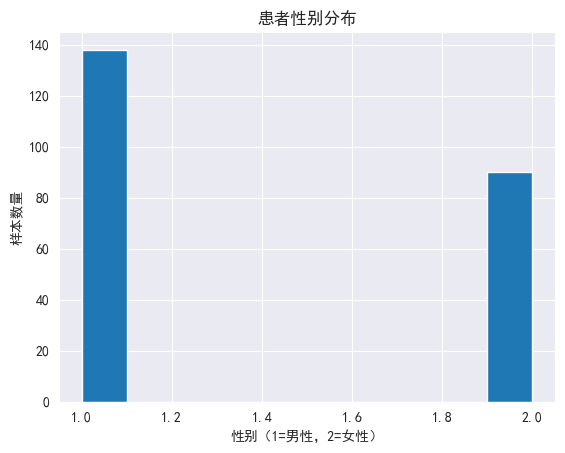

In [7]:
# 绘制患者性别分布直方图，了解分组特征分布
print("患者性别分布直方图：")
data["sex"].hist()  # 解析：sex=1(男性)、sex=2(女性)，查看男女患者样本量差异
plt.title("患者性别分布")
plt.xlabel("性别（1=男性，2=女性）")
plt.ylabel("样本数量")
plt.show()

In [8]:
###########################################################################
# 模块2：生存状态变量预处理（目的：转换为lifelines要求的二值化事件标记格式）
###########################################################################
"""
模块2核心功能：
1. 解析原始status字段含义（1=删失，2=死亡事件发生
2. 转换为dead字段（0=删失，1=事件发生），适配模型输入要求
"""

# 原始status字段说明：
# status=1：删失数据（患者未死亡，可能失访/研究结束仍存活，无完整生存时间）
# status=2：事件数据（患者因肺癌死亡，获取完整生存时间）
# 新建dead字段，转换生存状态（二值化，符合lifelines模型的event_observed参数要求）
data.loc[data.status == 1, 'dead'] = 0  # 删失→0（无事件发生）
data.loc[data.status == 2, 'dead'] = 1  # 死亡→1（事件发生）

# 查看转换后的数据前5行，验证预处理结果
data.head()  # 解析：新增dead字段，标记是否发生死亡事件，为模型拟合做准备

,Unnamed: 0,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss,dead
0,1,3.0,306,2,74,1,1.0,90.0,100.0,1175.0,NaN,1.0
1,2,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0,1.0
2,3,3.0,1010,1,56,1,0.0,90.0,90.0,NaN,15.0,0.0
3,4,5.0,210,2,57,1,1.0,90.0,60.0,1150.0,11.0,1.0
4,5,1.0,883,2,60,1,0.0,100.0,90.0,NaN,0.0,1.0


In [9]:
###########################################################################
# 模块3：Kaplan-Meier(KM)模型拟合与生存概率计算（目的：拟合模型，理解生存概率底层逻辑）
###########################################################################

"""
模块3核心功能：
1. 初始化并拟合KM模型，基于随访时间和生存状态
2. 手动计算条件生存概率/累积生存概率（理解乘积限法）
3. 自动预测生存概率（高效获取结果，对比手动计算）
"""

# 步骤1：初始化KaplanMeierFitter模型对象
kmf = KaplanMeierFitter()  # 解析：无参数模型，无需预设分布，适用于估计生存概率

# 步骤2：拟合模型（核心参数：持续时间+事件是否发生）
kmf.fit(
durations=data["time"],  # 必传参数：持续时间/生存时间，此处为患者随访天数
event_observed=data["dead"]  # 必传参数：事件是否发生，此处为转换后的dead字段（0/1）
)  # 解析：拟合后模型生成event_table、survival_function_等核心结果

# 步骤3：查看模型事件表（理解风险集变化和事件发生情况）
print("\nKM模型事件表：")
print(kmf.event_table)  # 解析：事件表字段说明
# at_risk：某时间点初始时，处于风险集的患者数（存活且未删失）
# observed：该时间点发生死亡事件的患者数
# censored：该时间点发生删失的患者数
# removed：该时间点离开风险集的总人数（removed=observed+censored）


KM模型事件表：
          removed  observed  censored  entrance  at_risk
event_at                                                
0.0             0         0         0       228      228
5.0             1         1         0         0      228
11.0            3         3         0         0      227
12.0            1         1         0         0      224
13.0            2         2         0         0      223
...           ...       ...       ...       ...      ...
840.0           1         0         1         0        5
883.0           1         1         0         0        4
965.0           1         0         1         0        3
1010.0          1         0         1         0        2
1022.0          1         0         1         0        1

[187 rows x 5 columns]


In [10]:
# 步骤4：手动计算单个时间点的「条件生存概率」（某时间点风险集患者存活的概率）
# 公式：条件生存概率 = (at_risk - observed) / at_risk
event_at_0 = kmf.event_table.iloc[0, :]  # 提取t=0对应的事件表行
surv_for_0 = (event_at_0.at_risk - event_at_0.observed) / event_at_0.at_risk  # t=0的条件生存概率
event_at_5 = kmf.event_table.iloc[1, :]  # 提取t=5对应的事件表行
surv_for_5 = (event_at_5.at_risk - event_at_5.observed) / event_at_5.at_risk  # t=5的条件生存概率
event_at_11 = kmf.event_table.iloc[2, :]  # 提取t=11对应的事件表行
surv_for_11 = (event_at_11.at_risk - event_at_11.observed) / event_at_11.at_risk  # t=11的条件生存概率

# 步骤5：手动计算「累积生存概率」（乘积限法：各时间点条件生存概率的乘积）
# 解析：患者要存活到t时刻，必须在之前所有时间点都存活，故采用连乘
surv_after_0 = surv_for_0  # t=0的累积生存概率（初始状态，无事件发生）
print("\n手动计算 - 存活0天的累积生存概率：", surv_after_0)

surv_after_5 = surv_for_0 * surv_for_5  # t=5的累积生存概率（t=0和t=5条件概率乘积）
print("手动计算 - 存活5天的累积生存概率：", surv_after_5)

surv_after_11 = surv_for_0 * surv_for_5 * surv_for_11  # 修正原代码缺失，完成连乘
print("手动计算 - 存活11天的累积生存概率：", surv_after_11)


手动计算 - 存活0天的累积生存概率： 1.0
手动计算 - 存活5天的累积生存概率： 0.9956140350877193
手动计算 - 存活11天的累积生存概率： 0.9824561403508771


In [11]:
# 步骤6：自动预测生存概率（lifelines内置方法，高效准确，优先用于实际分析）
print("\n自动预测 - 存活0天的生存概率：", kmf.predict(0))
print("自动预测 - 存活5天的生存概率：", kmf.predict(5))
print("自动预测 - 存活11天的生存概率：", kmf.predict(11))


自动预测 - 存活0天的生存概率： 1.0
自动预测 - 存活5天的生存概率： 0.9956140350877193
自动预测 - 存活11天的生存概率： 0.9824561403508766


In [12]:
# 步骤7：多时间点批量预测
multi_time_surv = kmf.predict([0, 5, 11, 12])
print("\n批量预测多时间点生存概率：", multi_time_surv)


批量预测多时间点生存概率： 0     1.000000
5     0.995614
11    0.982456
12    0.978070
Name: KM_estimate, dtype: float64


In [13]:
# 步骤8：获取完整生存函数表（所有时间点的累积生存概率）
full_survival_func = kmf.survival_function_
print("\n完整生存函数表（前5行）：")
print(full_survival_func.head())  # 解析：绘制生存曲线的核心数据，横轴time，纵轴survival概率


完整生存函数表（前5行）：
          KM_estimate
timeline             
0.0          1.000000
5.0          0.995614
11.0         0.982456
12.0         0.978070
13.0         0.969298


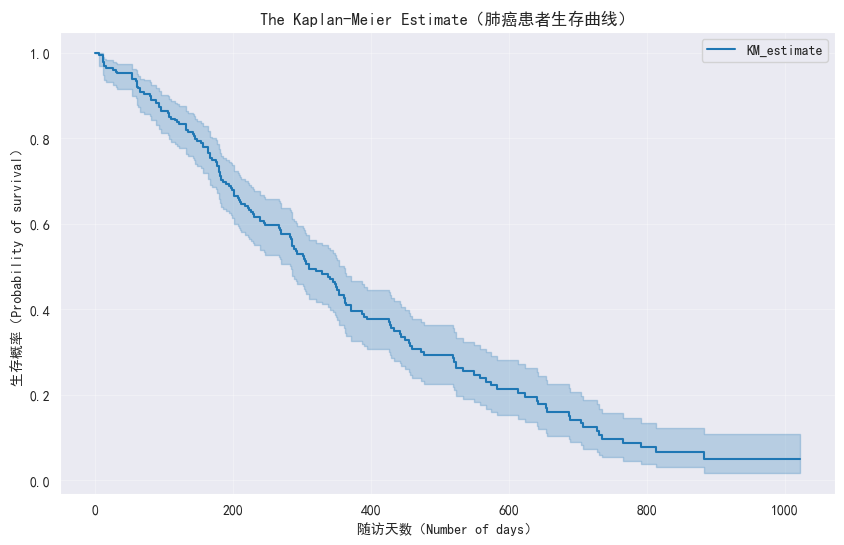

In [14]:
###########################################################################
# 模块4：KM生存函数结果提取与可视化（目的：可视化生存率，提取核心评价指标）
###########################################################################

"""
模块4核心功能：
1. 绘制基础生存曲线，解读生存率随时间变化趋势
2. 提取中位生存时间（核心评价指标）
3. 可视化生存概率的95%置信区间，反映估计不确定性
"""

# 步骤1：绘制基础KM生存曲线
plt.figure(figsize=(10, 6))
kmf.plot()  # 直接绘制生存曲线（阶梯式下降，仅在死亡事件发生时下降）
plt.title("The Kaplan-Meier Estimate（肺癌患者生存曲线）")
plt.xlabel("随访天数（Number of days）")
plt.ylabel("生存概率（Probability of survival）")
plt.grid(alpha=0.3)
plt.show()  # 解析：曲线越平缓，说明患者生存率随时间下降越慢，预后越好

In [15]:
# 步骤2：提取中位生存时间（核心指标）
median_surv_time = kmf.median_survival_time_
print("\n肺癌患者中位生存时间（50%患者存活的天数）：", median_surv_time)
# 解析：中位生存时间比平均生存时间稳健，不受极端值和删失数据影响


肺癌患者中位生存时间（50%患者存活的天数）： 310.0


In [16]:
# 步骤3：获取生存概率的95%置信区间
confidence_surv_func = kmf.confidence_interval_survival_function_
print("\n生存概率95%置信区间（前5行）：")
print(confidence_surv_func.head())  # 解析：包含lower（下限）和upper（上限），反映估计精度


生存概率95%置信区间（前5行）：
      KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.0                 1.000000                1.000000
5.0                 0.969277                0.999381
11.0                0.953935                0.993379
12.0                0.948120                0.990813
13.0                0.936682                0.985244


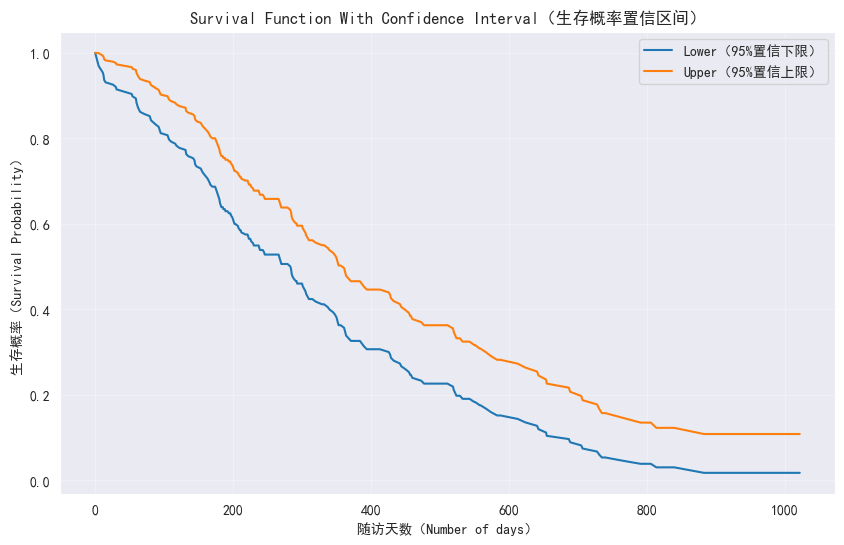

In [17]:
# 步骤4：可视化生存概率的置信区间
plt.figure(figsize=(10, 6))
plt.plot(confidence_surv_func["KM_estimate_lower_0.95"], label="Lower（95%置信下限）")
plt.plot(confidence_surv_func["KM_estimate_upper_0.95"], label="Upper（95%置信上限）")
plt.title("Survival Function With Confidence Interval（生存概率置信区间）")
plt.xlabel("随访天数（Number of days）")
plt.ylabel("生存概率（Survival Probability）")
plt.legend()
plt.grid(alpha=0.3)
plt.show()  # 解析：置信区间越窄，估计结果越可靠；时间越久，风险集越小，区间越宽

In [18]:
###########################################################################
# 模块5：累积死亡概率（累积密度）分析（目的：分析死亡事件的累积趋势
###########################################################################

"""
模块5核心功能：
1. 提取累积密度（累积死亡概率），与生存概率形成互补
2. 可视化累积密度曲线，解读死亡事件累积趋势
3. 可视化累积密度的置信区间，反映估计不确定性
"""

# 步骤1：获取累积密度（累积死亡概率）
cumulative_density = kmf.cumulative_density_
print("\n累积死亡概率表（前5行）：")
print(cumulative_density.head())  # 解析：累积密度F(t) = 1 - 生存概率S(t)


累积死亡概率表（前5行）：
          KM_estimate
timeline             
0.0          0.000000
5.0          0.004386
11.0         0.017544
12.0         0.021930
13.0         0.030702


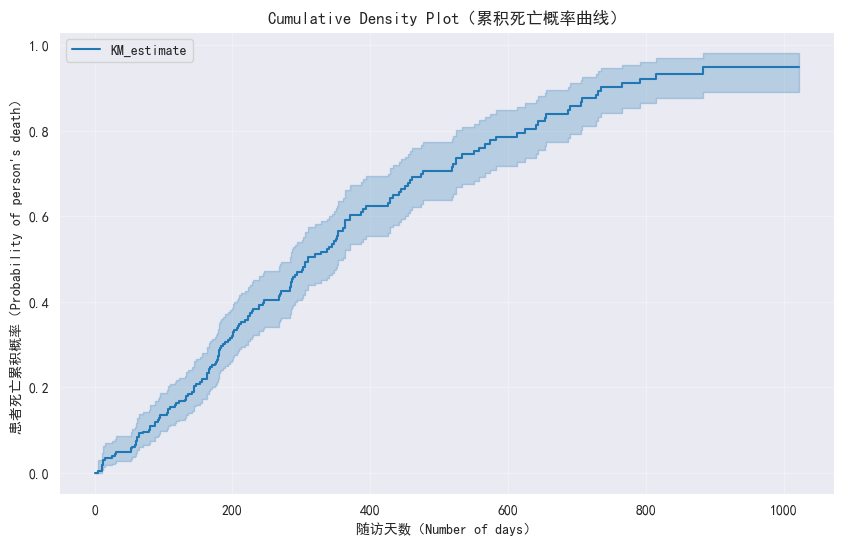

In [19]:
# 步骤2：绘制累积密度曲线
plt.figure(figsize=(10, 6))
kmf.plot_cumulative_density()
plt.title("Cumulative Density Plot（累积死亡概率曲线）")
plt.xlabel("随访天数（Number of days）")
plt.ylabel("患者死亡累积概率（Probability of person's death）")
plt.grid(alpha=0.3)
plt.show()  # 解析：阶梯式上升，反映随时间推移，患者死亡的累积概率变化

In [20]:
# 步骤3：获取累积密度的95%置信区间
confidence_cumulative_density = kmf.confidence_interval_cumulative_density_
print("\n累积死亡概率95%置信区间（前5行）：")
print(confidence_cumulative_density.head())


累积死亡概率95%置信区间（前5行）：
      KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.0                 0.000000                0.000000
5.0                 0.000619                0.030723
11.0                0.006621                0.046065
12.0                0.009187                0.051880
13.0                0.014756                0.063318


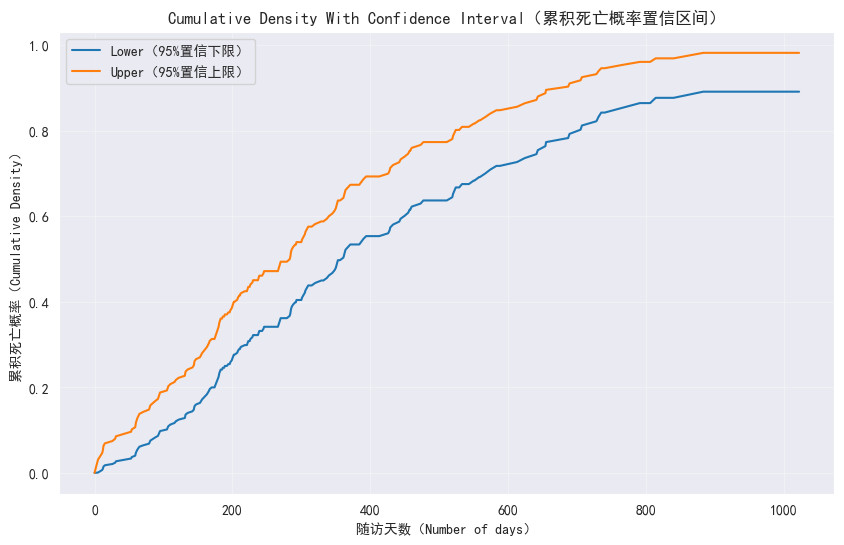

In [21]:
# 步骤4：可视化累积密度的置信区间
plt.figure(figsize=(10, 6))
plt.plot(kmf.confidence_interval_cumulative_density_["KM_estimate_lower_0.95"], label="Lower（95%置信下限）")
plt.plot(kmf.confidence_interval_cumulative_density_["KM_estimate_upper_0.95"], label="Upper（95%置信上限）")
plt.title("Cumulative Density With Confidence Interval（累积死亡概率置信区间）")
plt.xlabel("随访天数（Number of days）")
plt.ylabel("累积死亡概率（Cumulative Density）")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
# 步骤5：预测特定时间点的累积死亡概率
cum_density_1022 = kmf.cumulative_density_at_times(times=1022)
print("\n随访1022天的累积死亡概率：", cum_density_1022)


随访1022天的累积死亡概率： 1022    0.949654
Name: KM_estimate, dtype: float64


In [23]:
###########################################################################
# 模块6：条件中位事件时间分析（目的：为存活患者提供后续生存预期）
###########################################################################

"""
模块6核心功能：
1. 提取条件中位事件时间（已存活t天的患者，剩余的中位存活时间）
2. 可视化该指标，解读动态生存预期
"""

# 步骤1：获取条件中位事件时间
conditional_median_time = kmf.conditional_time_to_event_
print("\n条件中位事件时间表（前5行）：")
print(conditional_median_time.head())
# 解析：与普通中位生存时间的区别——普通中位是从t=0开始，该指标是「动态更新」，针对已存活t天的患者


条件中位事件时间表（前5行）：
          KM_estimate - Conditional median duration remaining to event
timeline                                                              
0.0                                                   310.0           
5.0                                                   305.0           
11.0                                                  309.0           
12.0                                                  308.0           
13.0                                                  316.0           


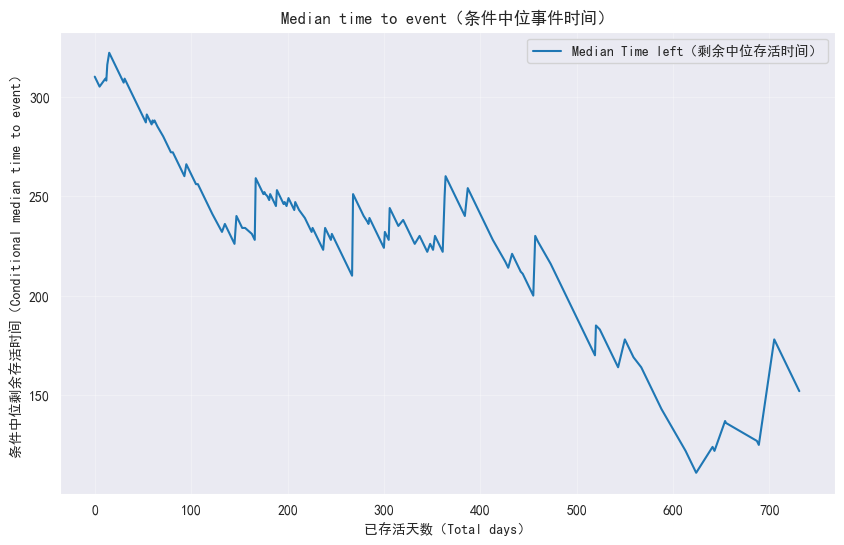

In [24]:
# 步骤2：可视化条件中位事件时间
plt.figure(figsize=(10, 6))
plt.plot(conditional_median_time, label="Median Time left（剩余中位存活时间）")
plt.title("Median time to event（条件中位事件时间）")
plt.xlabel("已存活天数（Total days）")
plt.ylabel("条件中位剩余存活时间（Conditional median time to event）")
plt.legend()
plt.grid(alpha=0.3)
plt.show()  # 解析：帮助临床医生为存活患者提供精准的后续生存预期

In [25]:
###########################################################################
# 模块7：Nelson-Aalen(NA)累积风险分析（目的：估计累积风险，补充KM模型结果）
###########################################################################

"""
模块7核心功能：
1. 初始化并拟合NA模型，估计累积风险函数
2. 可视化累积风险曲线，解读死亡风险累积趋势
3. 可视化累积风险的置信区间，反映风险估计的不确定性
"""

# 步骤1：导入NelsonAalenFitter模型，初始化对象
from lifelines import NelsonAalenFitter
naf = NelsonAalenFitter()  # 解析：无参数模型，专门用于估计累积风险函数

# 步骤2：拟合NA模型（参数与KM模型一致）
naf.fit(
durations=data["time"],
event_observed=data["dead"]
)  # 解析：拟合后生成cumulative_hazard_（累积风险表）

# 步骤3：获取累积风险表
cumulative_hazard = naf.cumulative_hazard_
print("\n累积风险表（前5行）：")
print(cumulative_hazard.head())
# 解析：风险函数h(t)是瞬时死亡率，累积风险H(t)是h(t)在[0,t]的积分，无取值上限


累积风险表（前5行）：
          NA_estimate
timeline             
0.0          0.000000
5.0          0.004386
11.0         0.017660
12.0         0.022125
13.0         0.031114


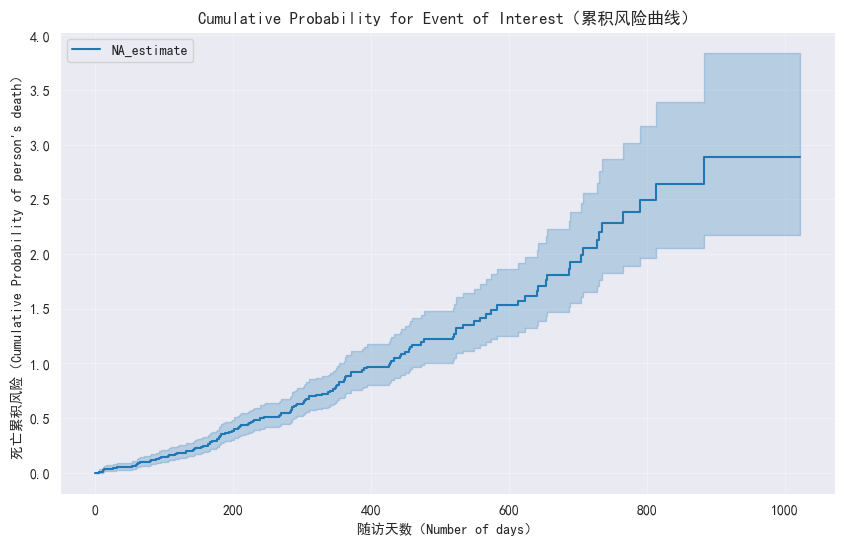

In [26]:
# 步骤4：绘制累积风险曲线
plt.figure(figsize=(10, 6))
naf.plot_cumulative_hazard()
plt.title("Cumulative Probability for Event of Interest（累积风险曲线）")
plt.xlabel("随访天数（Number of days）")
plt.ylabel("死亡累积风险（Cumulative Probability of person's death）")
plt.grid(alpha=0.3)
plt.show()

In [27]:
# 步骤5：预测特定时间点的累积风险
print("\n随访500天的累积风险：", naf.predict(500))
print("随访1022天的累积风险：", naf.predict(1022))

# 步骤6：获取累积风险的95%置信区间
confidence_interval_na = naf.confidence_interval_
print("\n累积风险95%置信区间（前5行）：")
print(confidence_interval_na.head())


随访500天的累积风险： 1.219546171331098
随访1022天的累积风险： 2.8915648373471052

累积风险95%置信区间（前5行）：
      NA_estimate_lower_0.95  NA_estimate_upper_0.95
0.0                 0.000000                0.000000
5.0                 0.000618                0.031136
11.0                0.006628                0.047055
12.0                0.009209                0.053156
13.0                0.014832                0.065266


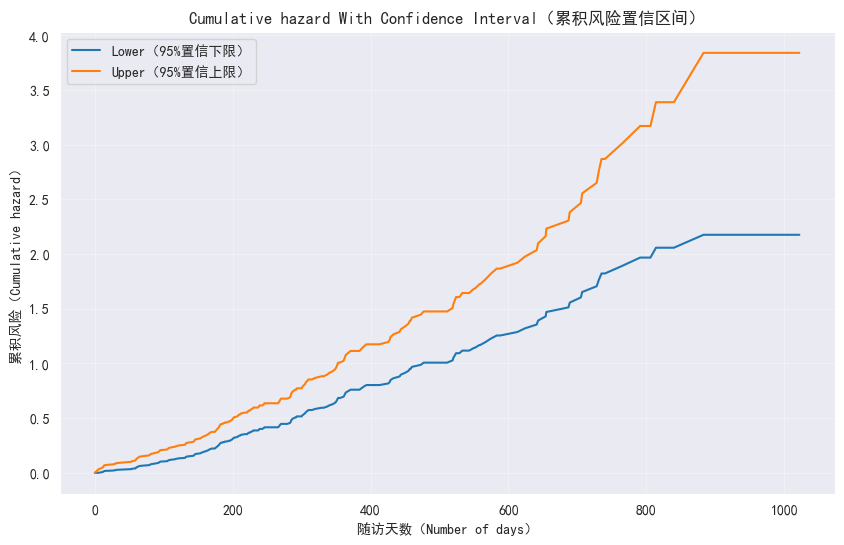

In [28]:
# 步骤7：可视化累积风险的置信区间
plt.figure(figsize=(10, 6))
plt.plot(confidence_interval_na["NA_estimate_lower_0.95"], label="Lower（95%置信下限）")
plt.plot(confidence_interval_na["NA_estimate_upper_0.95"], label="Upper（95%置信上限）")
plt.title("Cumulative hazard With Confidence Interval（累积风险置信区间）")
plt.xlabel("随访天数（Number of days）")
plt.ylabel("累积风险（Cumulative hazard）")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

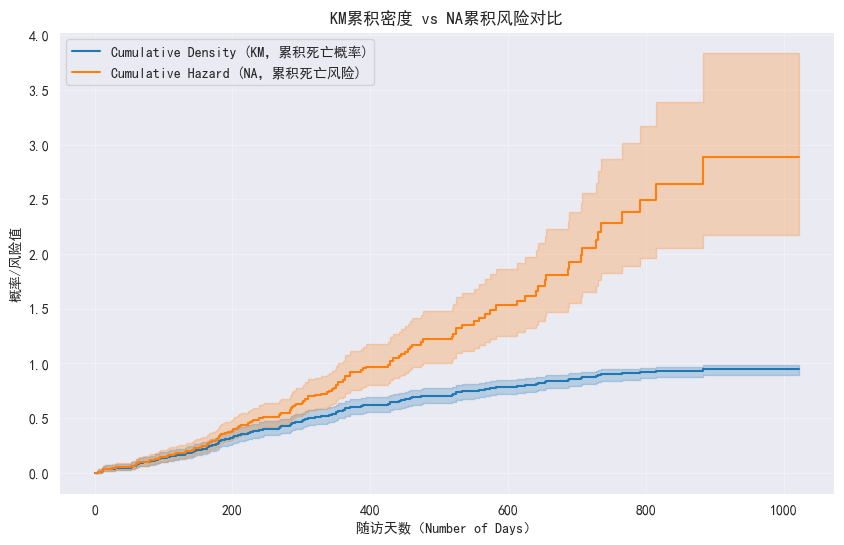

In [29]:
###########################################################################
# 模块8：KM累积密度与NA累积风险对比可视化（目的：对比两个核心指标的差异与一致性）
###########################################################################

"""
模块8核心功能：
1. 同图绘制KM累积密度与NA累积风险曲线
2. 解读两者的关系（低事件率时近似重合，高事件率时分离）
"""

plt.figure(figsize=(10, 6))
# 绘制KM累积密度（累积死亡概率）
kmf.plot_cumulative_density(label="Cumulative Density (KM，累积死亡概率)")
# 绘制NA累积风险（累积死亡风险）
naf.plot_cumulative_hazard(label="Cumulative Hazard (NA，累积死亡风险)")
plt.title("KM累积密度 vs NA累积风险对比")
plt.xlabel("随访天数（Number of Days）")
plt.ylabel("概率/风险值")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# 解析：低事件率阶段，F(t)≈H(t)，两条曲线重合；高事件率阶段，曲线分离（概率有上限0~1，风险无上限）
# 补充近似关系：生存概率S(t) ≈ exp(-H(t))（低事件率时）